5. Comparaison


---


In [ ]:
from pathlib import Path
import re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJ_ROOT = Path("..").resolve()
RUNS_ROOT = PROJ_ROOT / "out" / "experiments"
OUT_COMPARE = PROJ_ROOT / "out" / "compare"
OUT_COMPARE.mkdir(parents=True, exist_ok=True)

print("RUNS_ROOT:", RUNS_ROOT)
print("Exists:", RUNS_ROOT.exists())

RUNS_ROOT: /home/ui/PROJ8/out/experiments
Exists: True


In [ ]:
def read_json(path: Path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None


def list_run_dirs(runs_root: Path):
    if not runs_root.exists():
        return []
    return sorted([p for p in runs_root.iterdir() if p.is_dir()])


def find_first_existing(run_dir: Path, candidates):
    for name in candidates:
        p = run_dir / name
        if p.exists():
            return p
    return None


def safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan

In [ ]:
def parse_run_name(run_name: str):
    s = run_name.lower()

    # modèle / backbone
    model = None
    encoder = None
    mode = None

    if "unet" in s and "resnet" in s:
        model = "unet"
        encoder = "resnet50"
    elif "unet" in s and "vgg" in s:
        model = "unet"
        encoder = "vgg16"
    elif "vgg" in s:
        model = "unet"
        encoder = "vgg16"
    elif "resnet" in s:
        model = "unet"
        encoder = "resnet50"
    elif "unet" in s:
        model = "unet"
        encoder = "scratch"

    if "frozen" in s:
        mode = "frozen"
    elif "finetune" in s or "ft" in s or "trainable" in s:
        mode = "finetune"
    elif encoder == "scratch":
        mode = "scratch"

    # size HxW
    size_hw = None
    m = re.search(r"(\d{2,4})x(\d{2,4})", s)
    if m:
        size_hw = (int(m.group(1)), int(m.group(2)))

    # epochs e10 / epoch10 / _e10_
    epochs = None
    m = re.search(r"(?:_e|epoch)(\d+)", s)
    if m:
        epochs = int(m.group(1))

    # batch b4
    batch = None
    m = re.search(r"(?:_b|batch)(\d+)", s)
    if m:
        batch = int(m.group(1))

    # aug aug1/aug0
    aug = None
    m = re.search(r"aug(\d+)", s)
    if m:
        aug = bool(int(m.group(1)))

    # repeats rep2
    rep = None
    m = re.search(r"rep(\d+)", s)
    if m:
        rep = int(m.group(1))
    else:
        rep = 1

    # loss
    loss_name = None
    if "ce_dice" in s or "cedice" in s:
        loss_name = "ce_dice"
    elif "ce" in s:
        loss_name = "ce"

    return dict(
        model_family=model,
        encoder=encoder,
        train_mode=mode,
        size_hw=size_hw,
        epochs=epochs,
        batch=batch,
        aug=aug,
        aug_repeats=rep,
        loss_name=loss_name,
    )

In [ ]:
def extract_metrics_from_history(hist: dict):
    if not hist:
        return {}
    out = {}

    def get_series(keys):
        for k in keys:
            if k in hist and isinstance(hist[k], list) and len(hist[k]) > 0:
                return np.array(hist[k], dtype=np.float32)
        return None

    loss = get_series(["loss"])
    vloss = get_series(["val_loss"])
    miou = get_series(["mIoU", "miou"])
    vmiou = get_series(["val_mIoU", "val_miou"])

    if loss is not None:
        out["last_loss"] = float(loss[-1])
    if vloss is not None:
        out["last_val_loss"] = float(vloss[-1])
        best_i = int(np.argmin(vloss))
        out["best_val_loss"] = float(vloss[best_i])
        out["best_val_loss_epoch"] = best_i + 1

    if miou is not None:
        out["last_mIoU"] = float(miou[-1])
    if vmiou is not None:
        out["last_val_mIoU"] = float(vmiou[-1])
        best_i = int(np.argmax(vmiou))
        out["best_val_mIoU"] = float(vmiou[best_i])
        out["best_val_mIoU_epoch"] = best_i + 1

        tail = vmiou[-min(5, len(vmiou)) :]
        out["val_mIoU_tail_mean"] = float(np.mean(tail))
        out["val_mIoU_tail_std"] = float(np.std(tail))

    lr = get_series(["learning_rate", "lr"])
    if lr is not None:
        out["last_lr"] = float(lr[-1])

    out["n_epochs_ran"] = int(
        len(vloss) if vloss is not None else (len(loss) if loss is not None else 0)
    )
    return out

In [ ]:
run_dirs = list_run_dirs(RUNS_ROOT)
print("Nb runs:", len(run_dirs))

rows = []
for rd in run_dirs:
    run_name = rd.name
    summary = read_json(rd / "summary.json") or {}
    history = read_json(rd / "history.json") or {}

    parsed = parse_run_name(run_name)
    hist_metrics = extract_metrics_from_history(history)

    best_model = find_first_existing(
        rd, ["best_model.keras", f"{run_name}.keras", "model.keras"]
    )
    pred_grid = find_first_existing(rd, ["pred_grid.png", "predictions.png"])
    loss_png = find_first_existing(rd, ["loss.png"])
    miou_png = find_first_existing(rd, ["miou.png", "mIoU.png", "iou.png"])

    row = {
        "run_name": run_name,
        "run_dir": str(rd),
        **parsed,
        "val_loss": safe_float(summary.get("val_loss")),
        "val_mIoU": safe_float(summary.get("val_mIoU") or summary.get("val_miou")),
        "test_loss": safe_float(summary.get("test_loss")),
        "test_mIoU": safe_float(summary.get("test_mIoU") or summary.get("test_miou")),
        "train_time_sec": safe_float(summary.get("train_time_sec")),
        **hist_metrics,
        "best_model_path": str(best_model) if best_model else "",
        "pred_grid_png": str(pred_grid) if pred_grid else "",
        "loss_png": str(loss_png) if loss_png else "",
        "miou_png": str(miou_png) if miou_png else "",
    }
    rows.append(row)

df = pd.DataFrame(rows)

df["score_main"] = df["test_mIoU"]
df.loc[df["score_main"].isna(), "score_main"] = df["best_val_mIoU"]
df.loc[df["score_main"].isna(), "score_main"] = df["val_mIoU"]

df.sort_values("score_main", ascending=False).head(20)

Nb runs: 9


,run_name,run_dir,model_family,encoder,train_mode,size_hw,epochs,batch,aug,aug_repeats,...,best_val_mIoU_epoch,val_mIoU_tail_mean,val_mIoU_tail_std,last_lr,n_epochs_ran,best_model_path,pred_grid_png,loss_png,miou_png,score_main
6,UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e40_...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,unet,scratch,scratch,"(256, 256)",40.0,4,True,1,...,37,0.752612,0.001090,0.000250,40,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,0.771898
8,VGG16_FT_256x256_b4_aug1_ce_dice,/home/ui/PROJ8/out/experiments/VGG16_FT_256x25...,unet,vgg16,finetune,"(256, 256)",NaN,4,True,1,...,29,0.732845,0.013067,0.001000,30,/home/ui/PROJ8/out/experiments/VGG16_FT_256x25...,/home/ui/PROJ8/out/experiments/VGG16_FT_256x25...,/home/ui/PROJ8/out/experiments/VGG16_FT_256x25...,/home/ui/PROJ8/out/experiments/VGG16_FT_256x25...,0.768835
1,RESNET50_FT_256x256_b4_aug1_ce_dice,/home/ui/PROJ8/out/experiments/RESNET50_FT_256...,unet,resnet50,finetune,"(256, 256)",NaN,4,True,1,...,30,0.742447,0.002775,0.000125,30,,/home/ui/PROJ8/out/experiments/RESNET50_FT_256...,/home/ui/PROJ8/out/experiments/RESNET50_FT_256...,/home/ui/PROJ8/out/experiments/RESNET50_FT_256...,0.766461
0,RESNET50_FROZEN_256x256_b4_aug1_ce_dice,/home/ui/PROJ8/out/experiments/RESNET50_FROZEN...,unet,resnet50,frozen,"(256, 256)",NaN,4,True,1,...,37,0.743494,0.000485,0.000125,40,,/home/ui/PROJ8/out/experiments/RESNET50_FROZEN...,/home/ui/PROJ8/out/experiments/RESNET50_FROZEN...,/home/ui/PROJ8/out/experiments/RESNET50_FROZEN...,0.763939
7,VGG16_FROZEN_256x256_b4_aug1_ce_dice,/home/ui/PROJ8/out/experiments/VGG16_FROZEN_25...,unet,vgg16,frozen,"(256, 256)",NaN,4,True,1,...,38,0.716399,0.000503,0.000125,40,,/home/ui/PROJ8/out/experiments/VGG16_FROZEN_25...,/home/ui/PROJ8/out/experiments/VGG16_FROZEN_25...,/home/ui/PROJ8/out/experiments/VGG16_FROZEN_25...,0.739793
5,UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e10_...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,unet,scratch,scratch,"(256, 256)",10.0,4,True,1,...,10,0.648688,0.010604,0.001000,10,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,0.681464
4,UNET_SCRATCH_256x256_b4_aug0_rep1_ce_e5_seed42,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,unet,scratch,scratch,"(256, 256)",5.0,4,False,1,...,4,0.592870,0.047371,0.001000,5,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_25...,0.671014
2,UNET_SCRATCH_128x128_b8_aug0_rep1_ce_e5_seed42,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,unet,scratch,scratch,"(128, 128)",5.0,8,False,1,...,5,0.547898,0.084450,0.001000,5,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,0.648802
3,UNET_SCRATCH_128x128_b8_aug1_rep1_ce_e10_seed42,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,unet,scratch,scratch,"(128, 128)",10.0,8,True,1,...,10,0.583595,0.014095,0.001000,10,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,/home/ui/PROJ8/out/experiments/UNET_SCRATCH_12...,0.630923


In [ ]:
csv_path = OUT_COMPARE / "comparison_all_runs.csv"

df.to_csv(csv_path, index=False)

print("Saved:", csv_path)

Saved: /home/ui/PROJ8/out/compare/comparison_all_runs.csv


In [ ]:
cols_show = [
    "run_name",
    "model_family",
    "encoder",
    "train_mode",
    "size_hw",
    "epochs",
    "batch",
    "aug",
    "aug_repeats",
    "loss_name",
    "score_main",
    "test_mIoU",
    "best_val_mIoU",
    "val_mIoU",
    "best_val_mIoU_epoch",
    "best_val_loss",
    "train_time_sec",
    "val_mIoU_tail_std",
]

view = df.copy()
view = view[cols_show].sort_values("score_main", ascending=False)

view.head(30)

,run_name,model_family,encoder,train_mode,size_hw,epochs,batch,aug,aug_repeats,loss_name,score_main,test_mIoU,best_val_mIoU,val_mIoU,best_val_mIoU_epoch,best_val_loss,train_time_sec,val_mIoU_tail_std
6,UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e40_...,unet,scratch,scratch,"(256, 256)",40.0,4,True,1,ce_dice,0.771898,0.771898,0.753862,0.753862,37,0.350212,11925.037594,0.001090
8,VGG16_FT_256x256_b4_aug1_ce_dice,unet,vgg16,finetune,"(256, 256)",NaN,4,True,1,ce_dice,0.768835,0.768835,0.746516,0.746516,29,0.367844,10008.115596,0.013067
1,RESNET50_FT_256x256_b4_aug1_ce_dice,unet,resnet50,finetune,"(256, 256)",NaN,4,True,1,ce_dice,0.766461,0.766461,0.747068,0.747068,30,0.362071,13232.389510,0.002775
0,RESNET50_FROZEN_256x256_b4_aug1_ce_dice,unet,resnet50,frozen,"(256, 256)",NaN,4,True,1,ce_dice,0.763939,0.763939,0.744022,0.744022,37,0.377431,11552.668707,0.000485
7,VGG16_FROZEN_256x256_b4_aug1_ce_dice,unet,vgg16,frozen,"(256, 256)",NaN,4,True,1,ce_dice,0.739793,0.739793,0.717004,0.717004,38,0.424994,12095.548188,0.000503
5,UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e10_...,unet,scratch,scratch,"(256, 256)",10.0,4,True,1,ce_dice,0.681464,0.681464,0.659336,0.659336,10,0.526105,2958.684039,0.010604
4,UNET_SCRATCH_256x256_b4_aug0_rep1_ce_e5_seed42,unet,scratch,scratch,"(256, 256)",5.0,4,False,1,ce,0.671014,0.671014,0.647726,0.647726,4,0.345296,1466.444567,0.047371
2,UNET_SCRATCH_128x128_b8_aug0_rep1_ce_e5_seed42,unet,scratch,scratch,"(128, 128)",5.0,8,False,1,ce,0.648802,0.648802,0.628136,0.628136,5,0.367822,1182.343772,0.084450
3,UNET_SCRATCH_128x128_b8_aug1_rep1_ce_e10_seed42,unet,scratch,scratch,"(128, 128)",10.0,8,True,1,ce,0.630923,0.630923,0.604361,0.604361,10,0.418643,2367.653148,0.014095


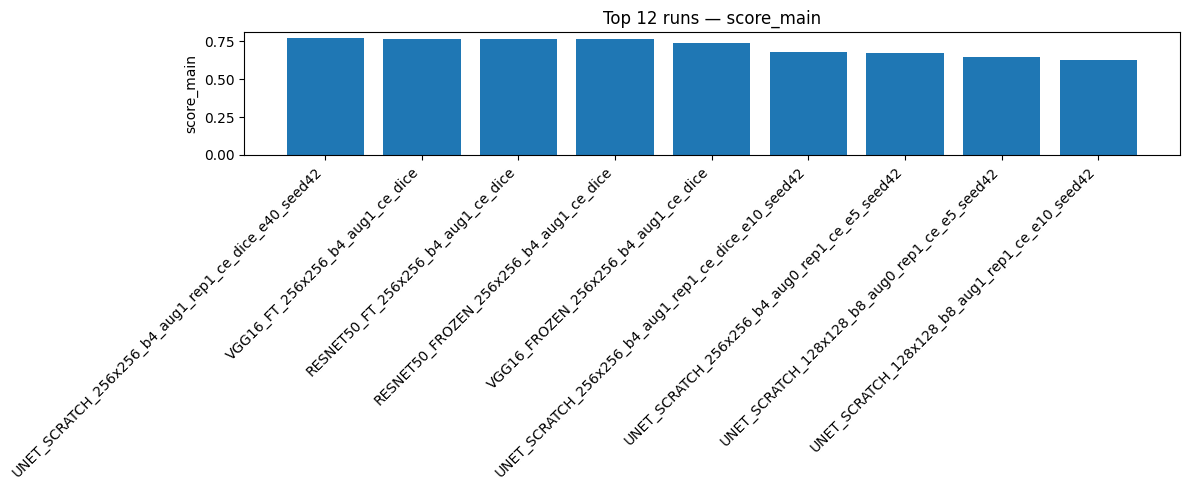

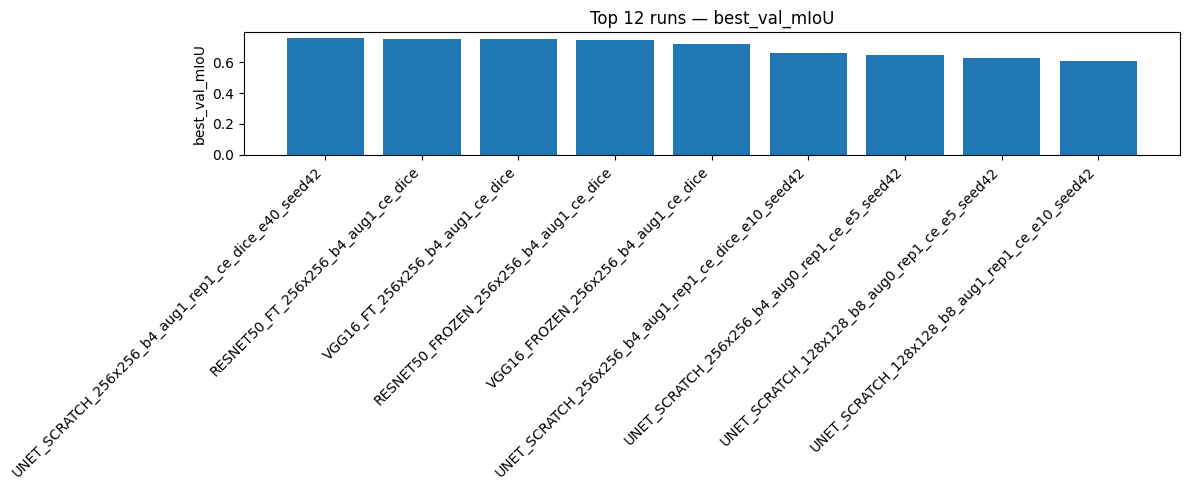

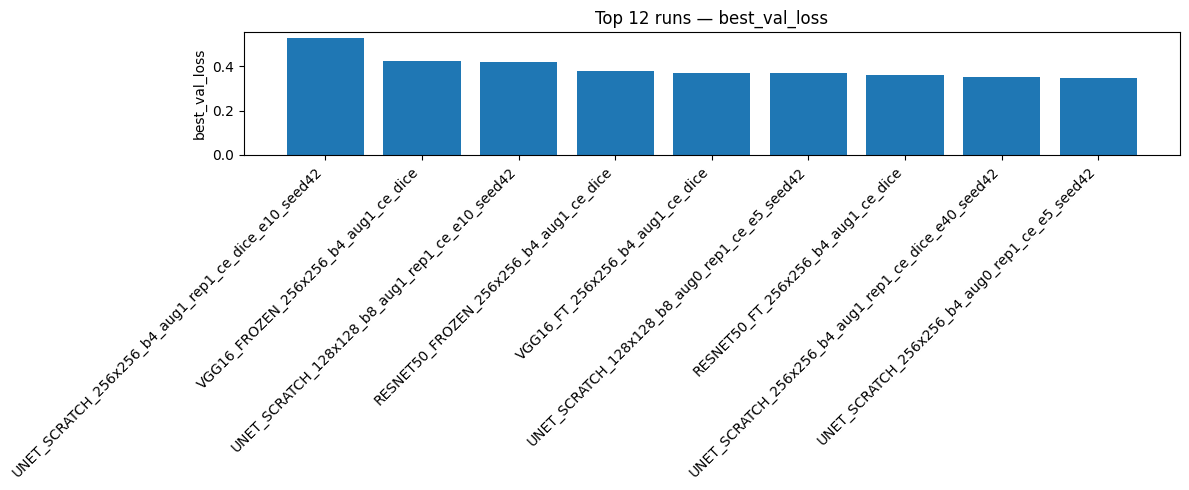

In [ ]:
def plot_topN(metric="score_main", N=10):
    d = df.sort_values(metric, ascending=False).head(N).copy()
    labels = d["run_name"].tolist()
    vals = d[metric].tolist()

    plt.figure(figsize=(12, 5))
    plt.bar(range(len(labels)), vals)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"Top {N} runs — {metric}")
    plt.tight_layout()
    plt.show()


plot_topN("score_main", 12)
plot_topN("best_val_mIoU", 12)
plot_topN("best_val_loss", 12)

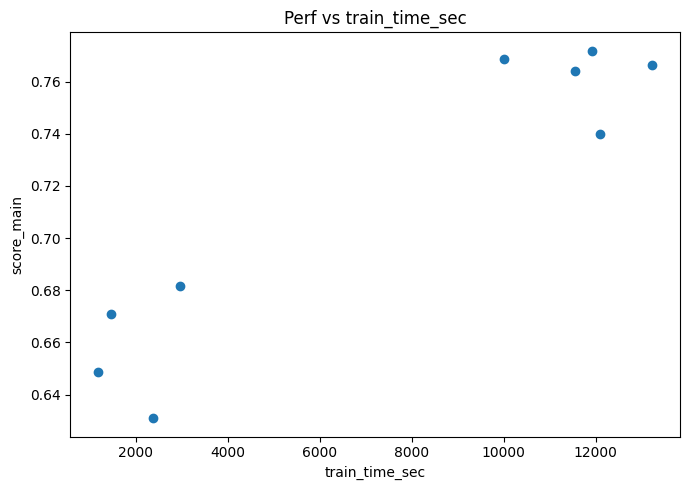

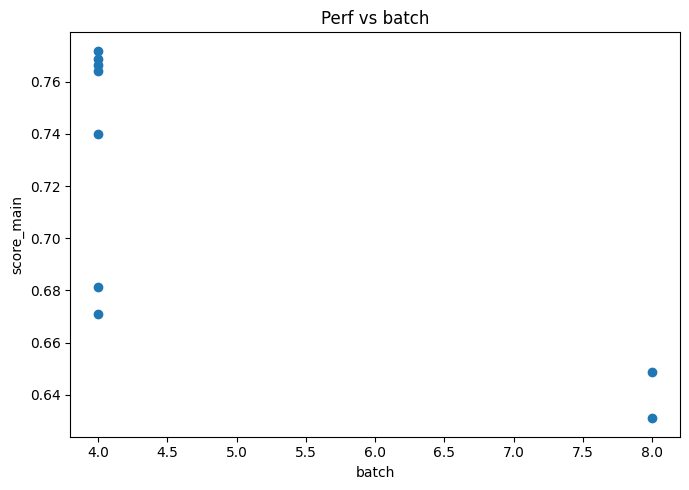

In [ ]:
def scatter(x, y, title):
    d = df.copy()
    d = d[np.isfinite(d[x]) & np.isfinite(d[y])]
    plt.figure(figsize=(7, 5))
    plt.scatter(d[x], d[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.tight_layout()
    plt.show()


scatter("train_time_sec", "score_main", "Perf vs train_time_sec")
scatter("batch", "score_main", "Perf vs batch")

In [ ]:
def group_summary(group_col="encoder", metric="score_main"):
    d = df.copy()
    d = d[np.isfinite(d[metric])]
    g = (
        d.groupby(group_col)[metric]
        .agg(["count", "mean", "max"])
        .sort_values("max", ascending=False)
    )
    return g


group_summary("encoder", "score_main")

,count,mean,max
encoder,,,
scratch,5,0.680820,0.771898
vgg16,2,0.754314,0.768835
resnet50,2,0.765200,0.766461


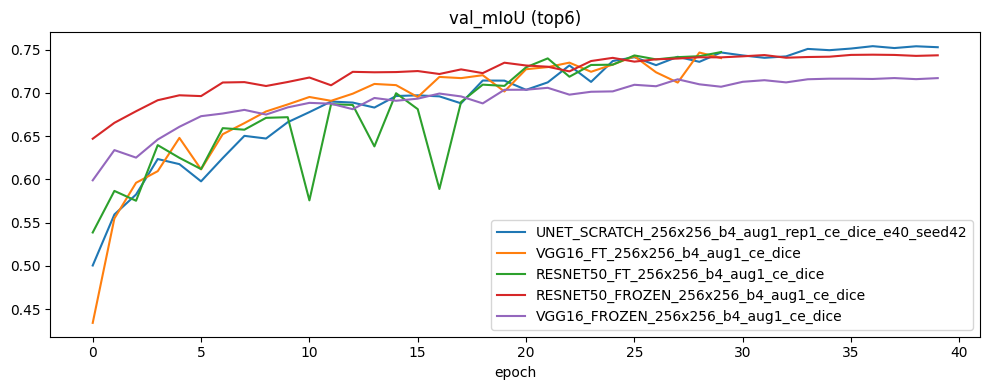

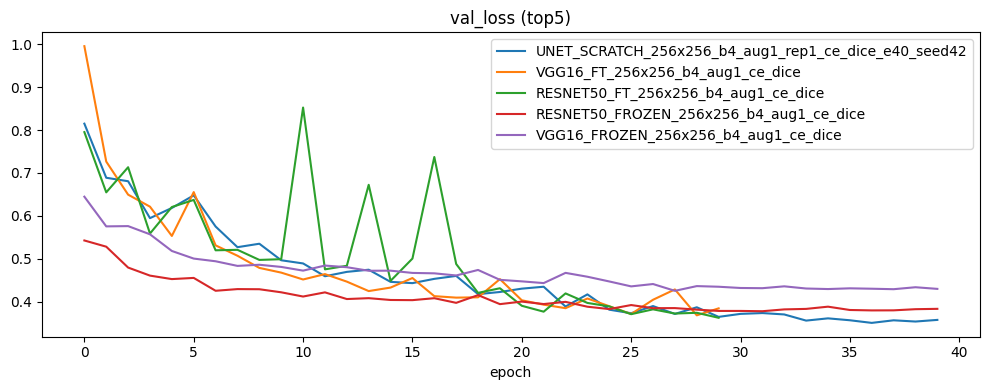

In [ ]:
def load_hist(run_name):
    p = RUNS_ROOT / run_name / "history.json"
    return read_json(p) or {}


def plot_metric(run_names, key_candidates, title):
    plt.figure(figsize=(10, 4))
    for rn in run_names:
        h = load_hist(rn)
        series = None
        for k in key_candidates:
            if k in h and isinstance(h[k], list) and len(h[k]) > 0:
                series = h[k]
                break
        if series is None:
            continue
        plt.plot(series, label=rn)
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()


best = df.sort_values("score_main", ascending=False).head(5)["run_name"].tolist()
plot_metric(best, ["val_mIoU", "val_miou"], "val_mIoU (top6)")
plot_metric(best, ["val_loss"], "val_loss (top5)")

Run: UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e40_seed42
Found images: ['pred_grid.png', 'loss.png', 'miou.png']


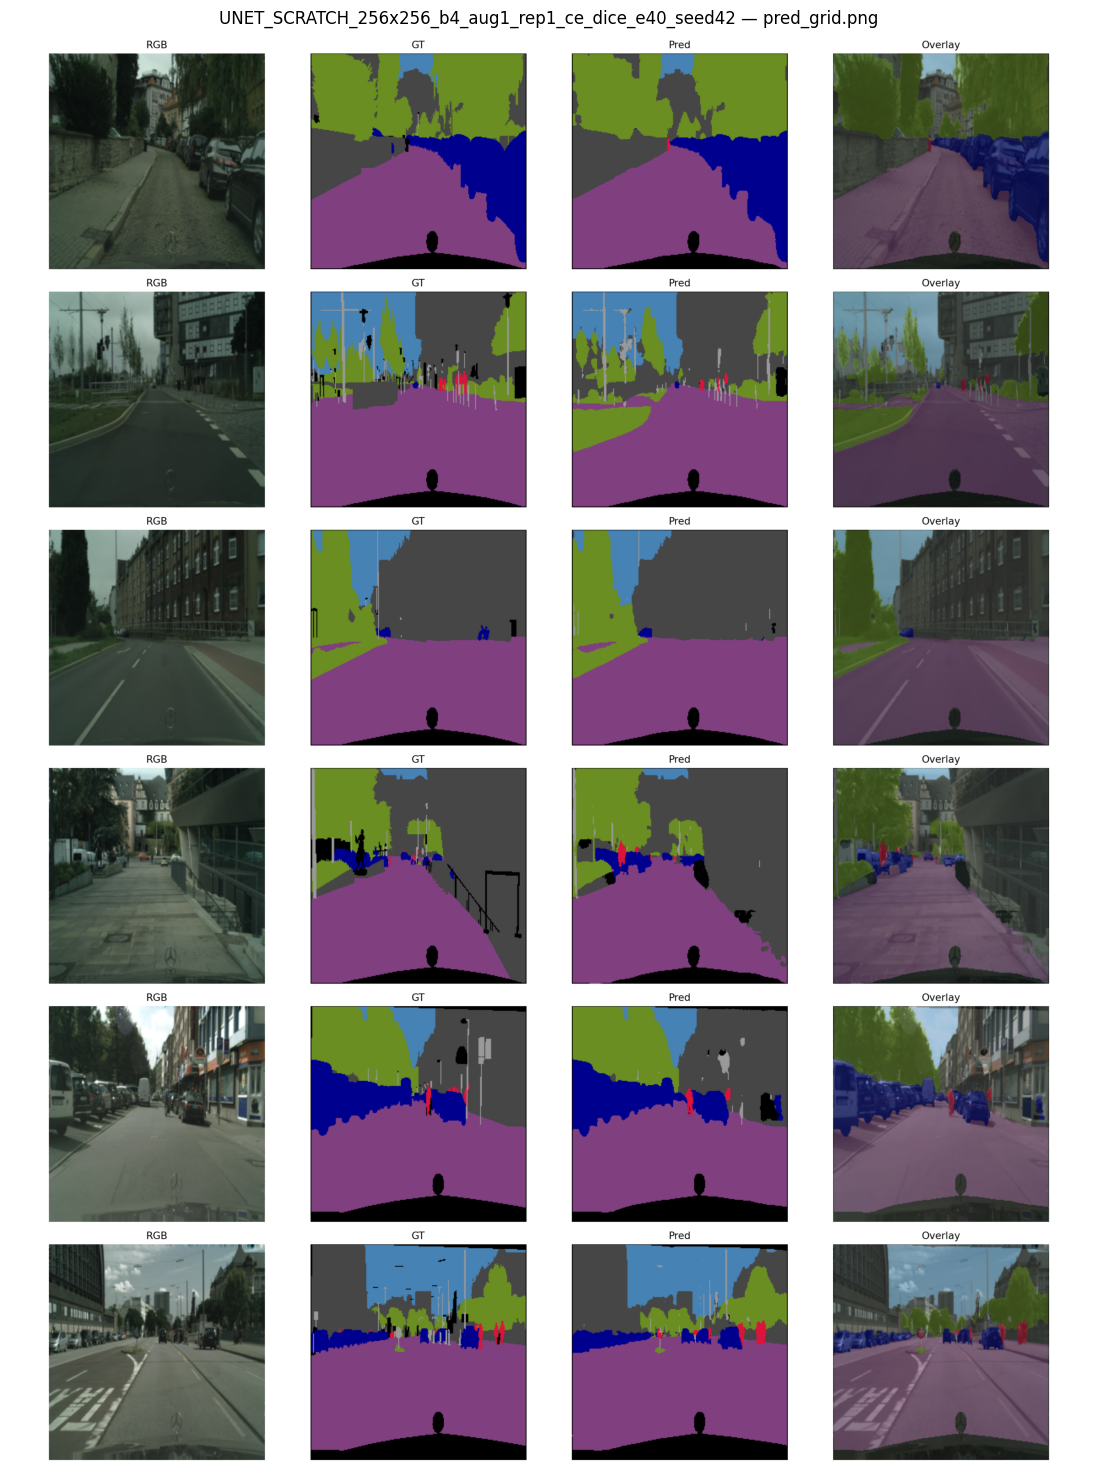

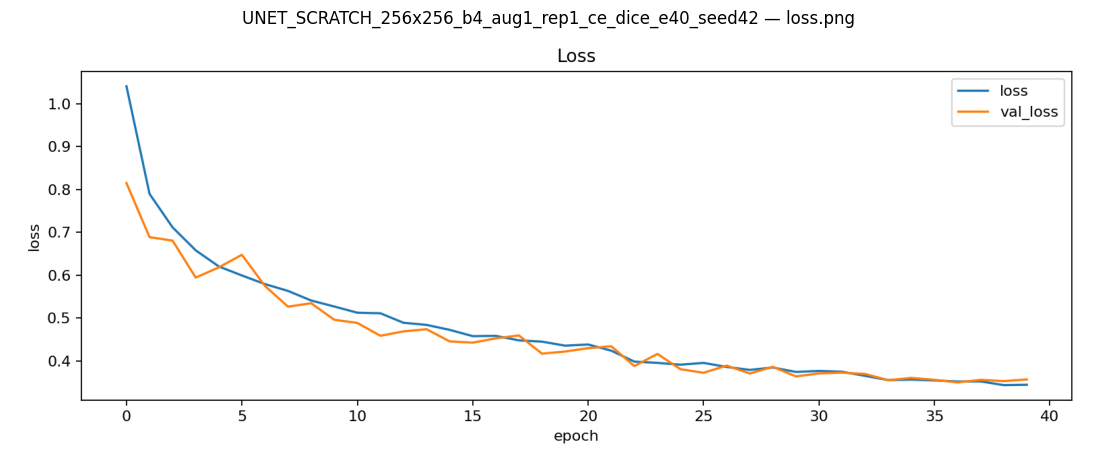

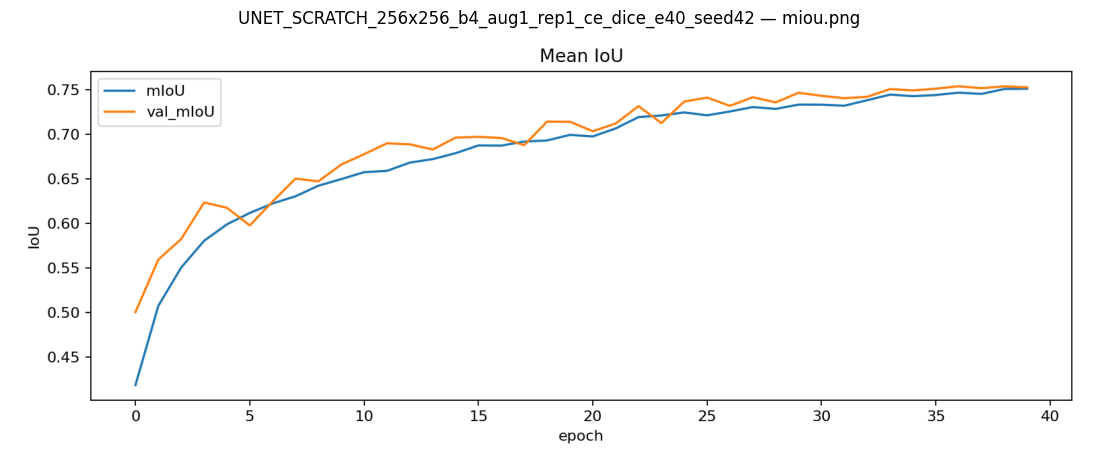

Run: VGG16_FT_256x256_b4_aug1_ce_dice
Found images: ['pred_grid.png', 'loss.png', 'miou.png']


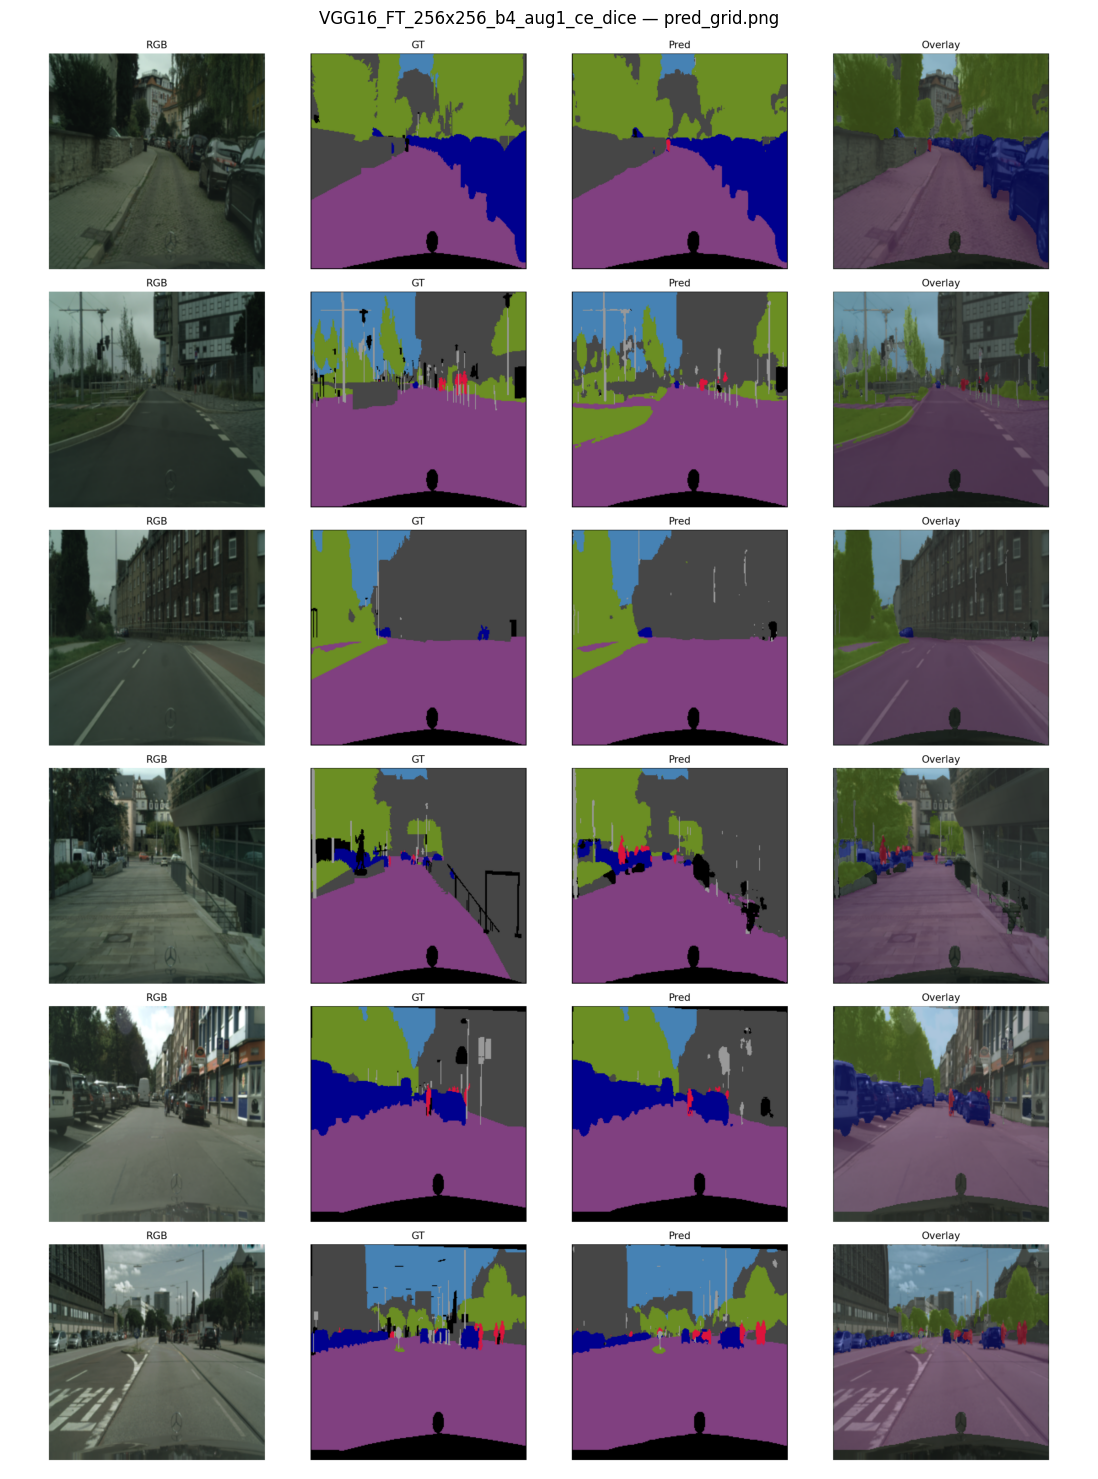

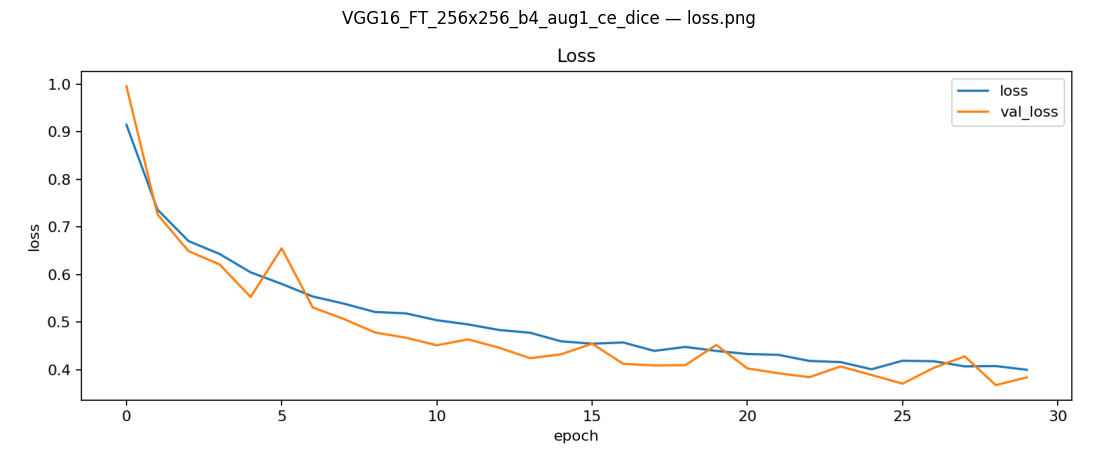

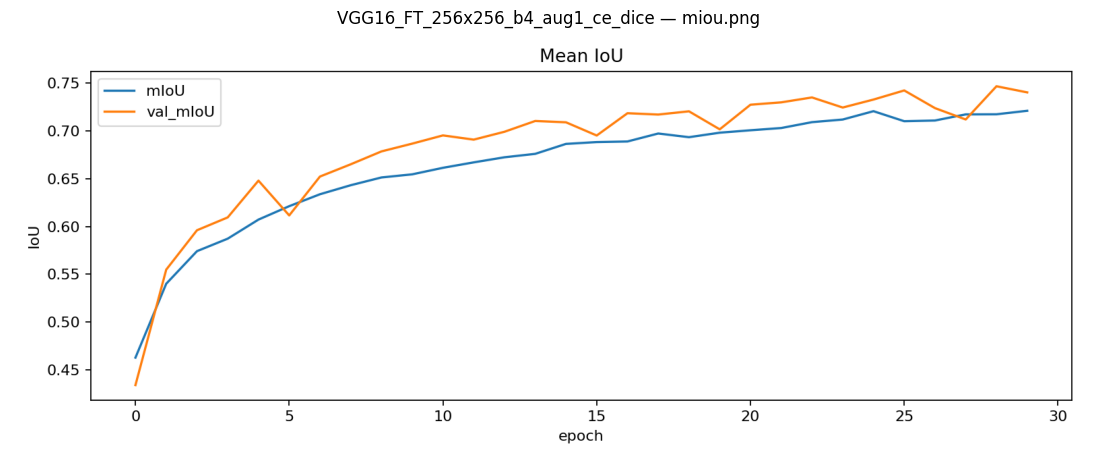

Run: RESNET50_FT_256x256_b4_aug1_ce_dice
Found images: ['pred_grid.png', 'loss.png', 'miou.png']


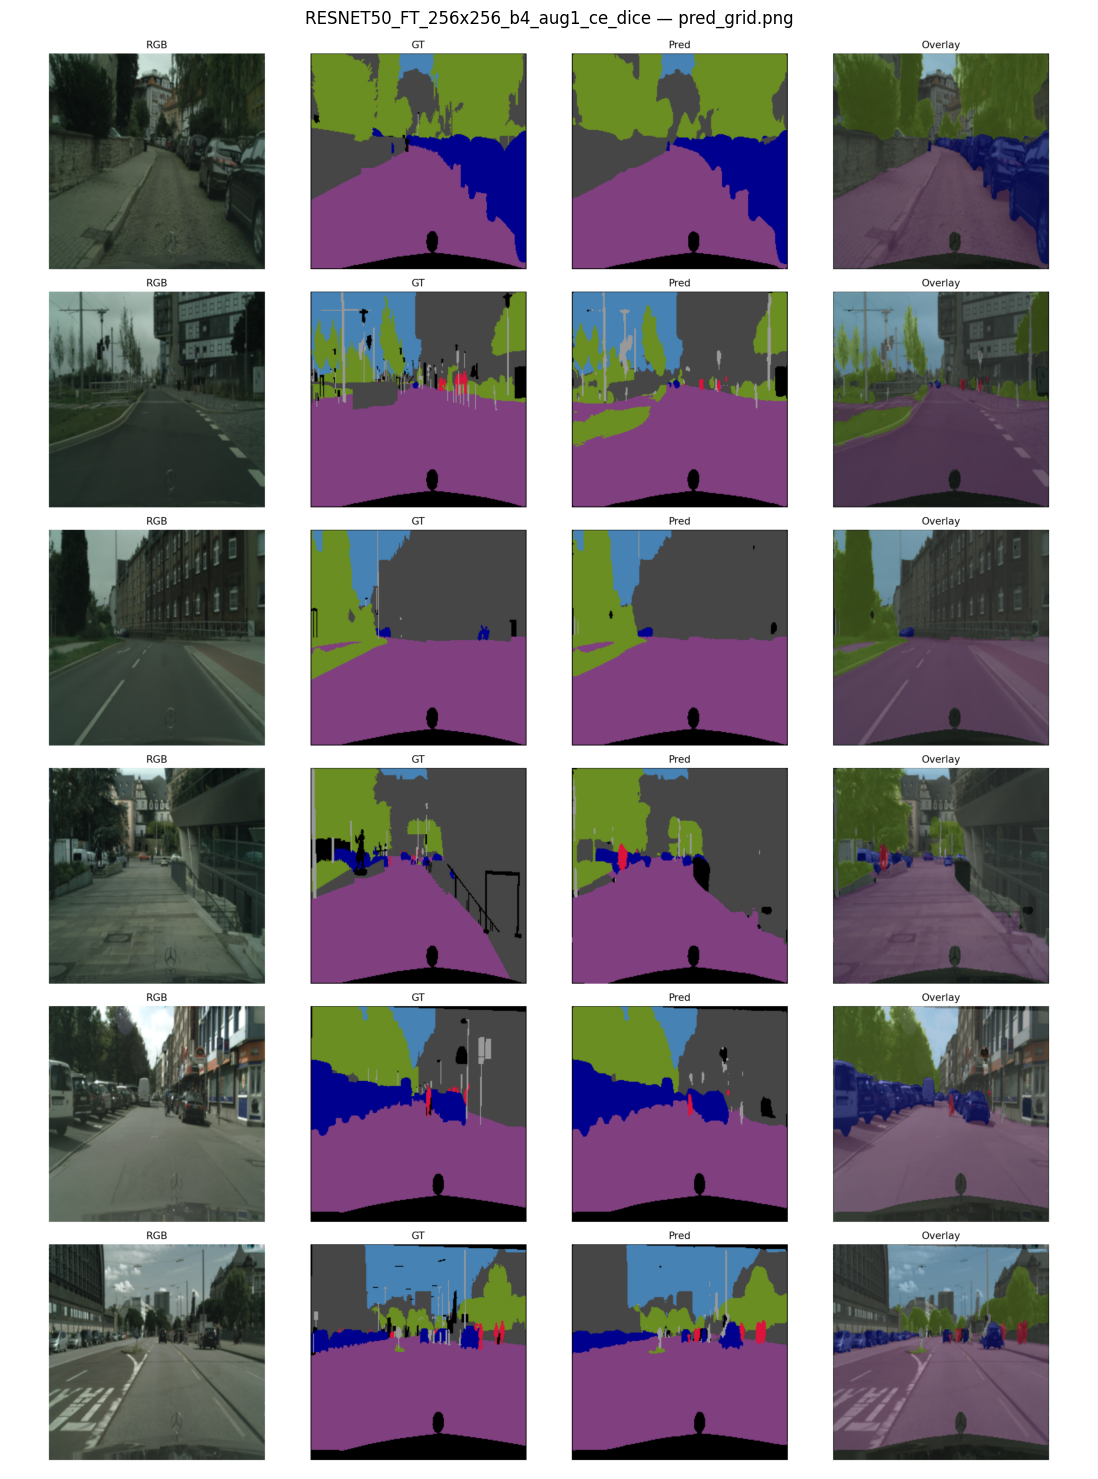

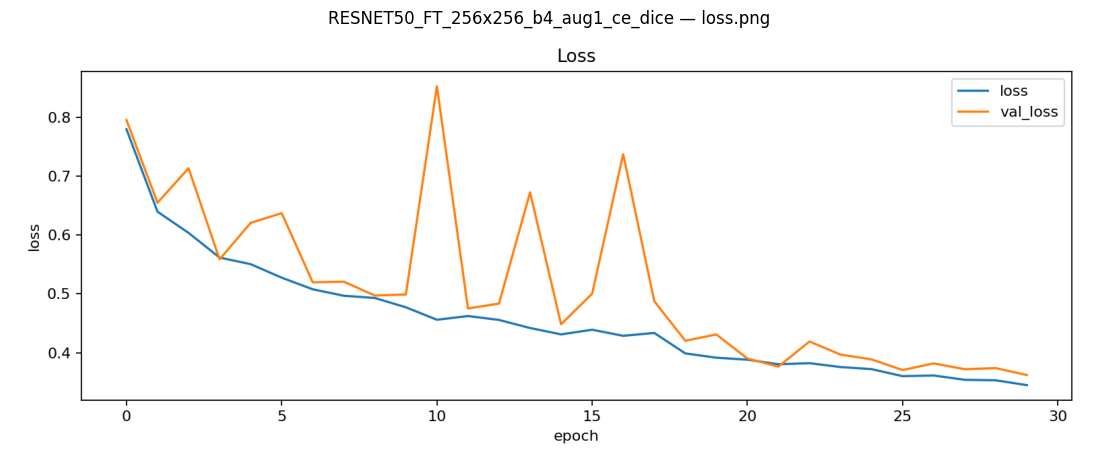

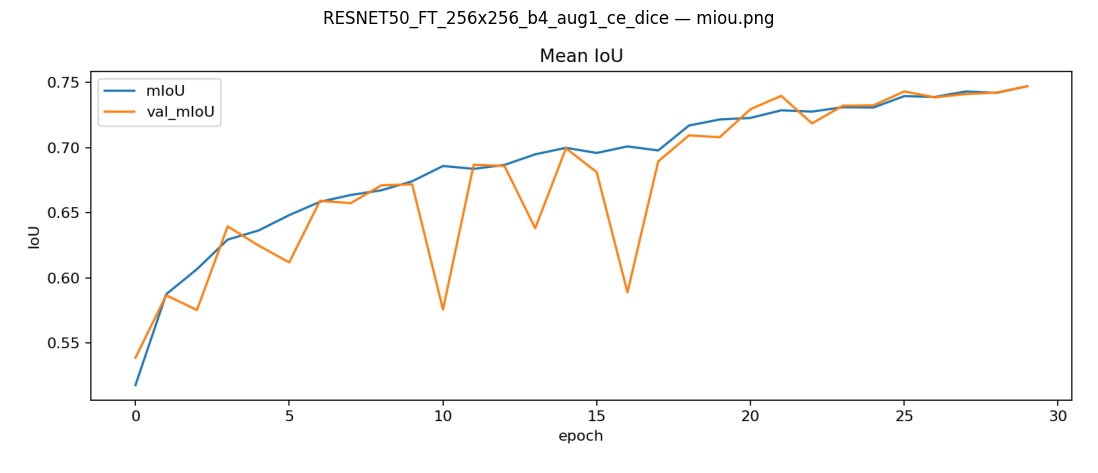

Run: RESNET50_FROZEN_256x256_b4_aug1_ce_dice
Found images: ['pred_grid.png', 'loss.png', 'miou.png']


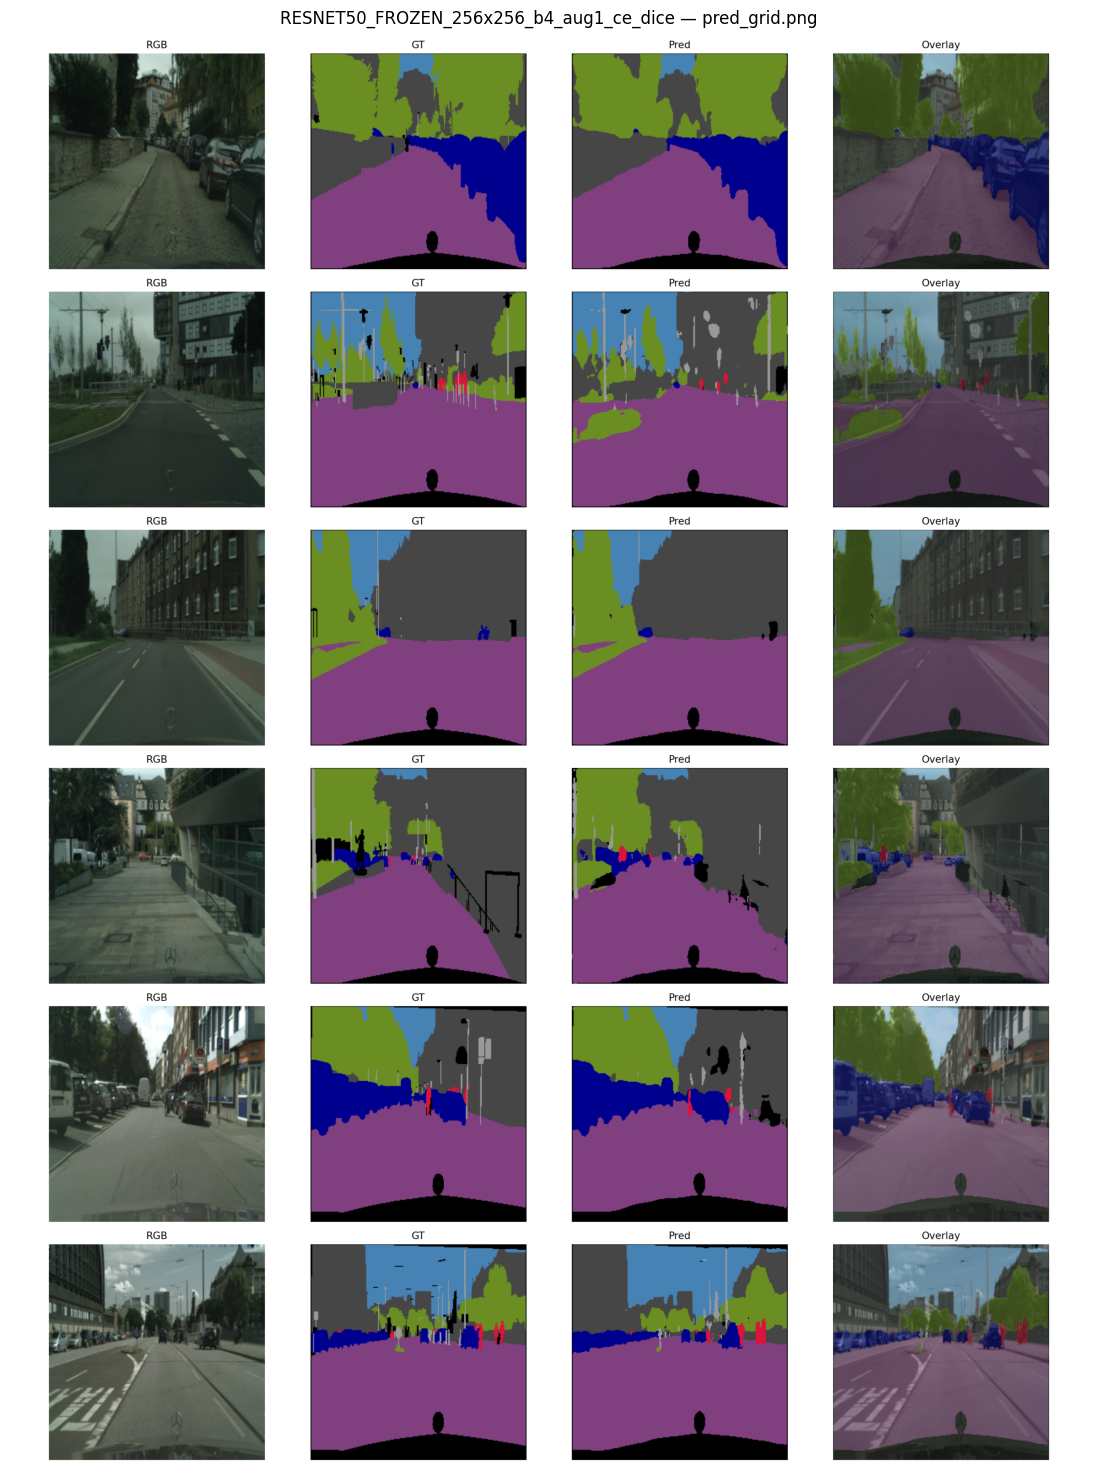

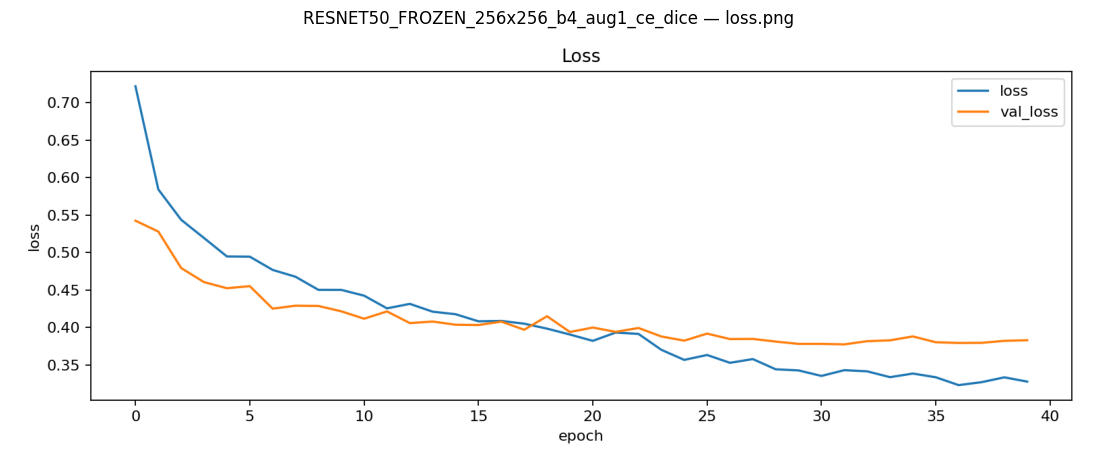

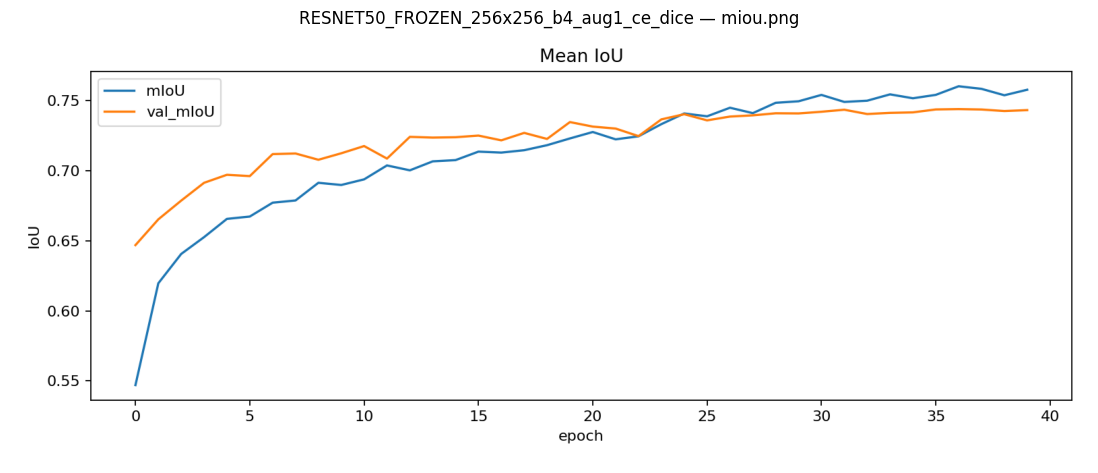

Run: VGG16_FROZEN_256x256_b4_aug1_ce_dice
Found images: ['pred_grid.png', 'loss.png', 'miou.png']


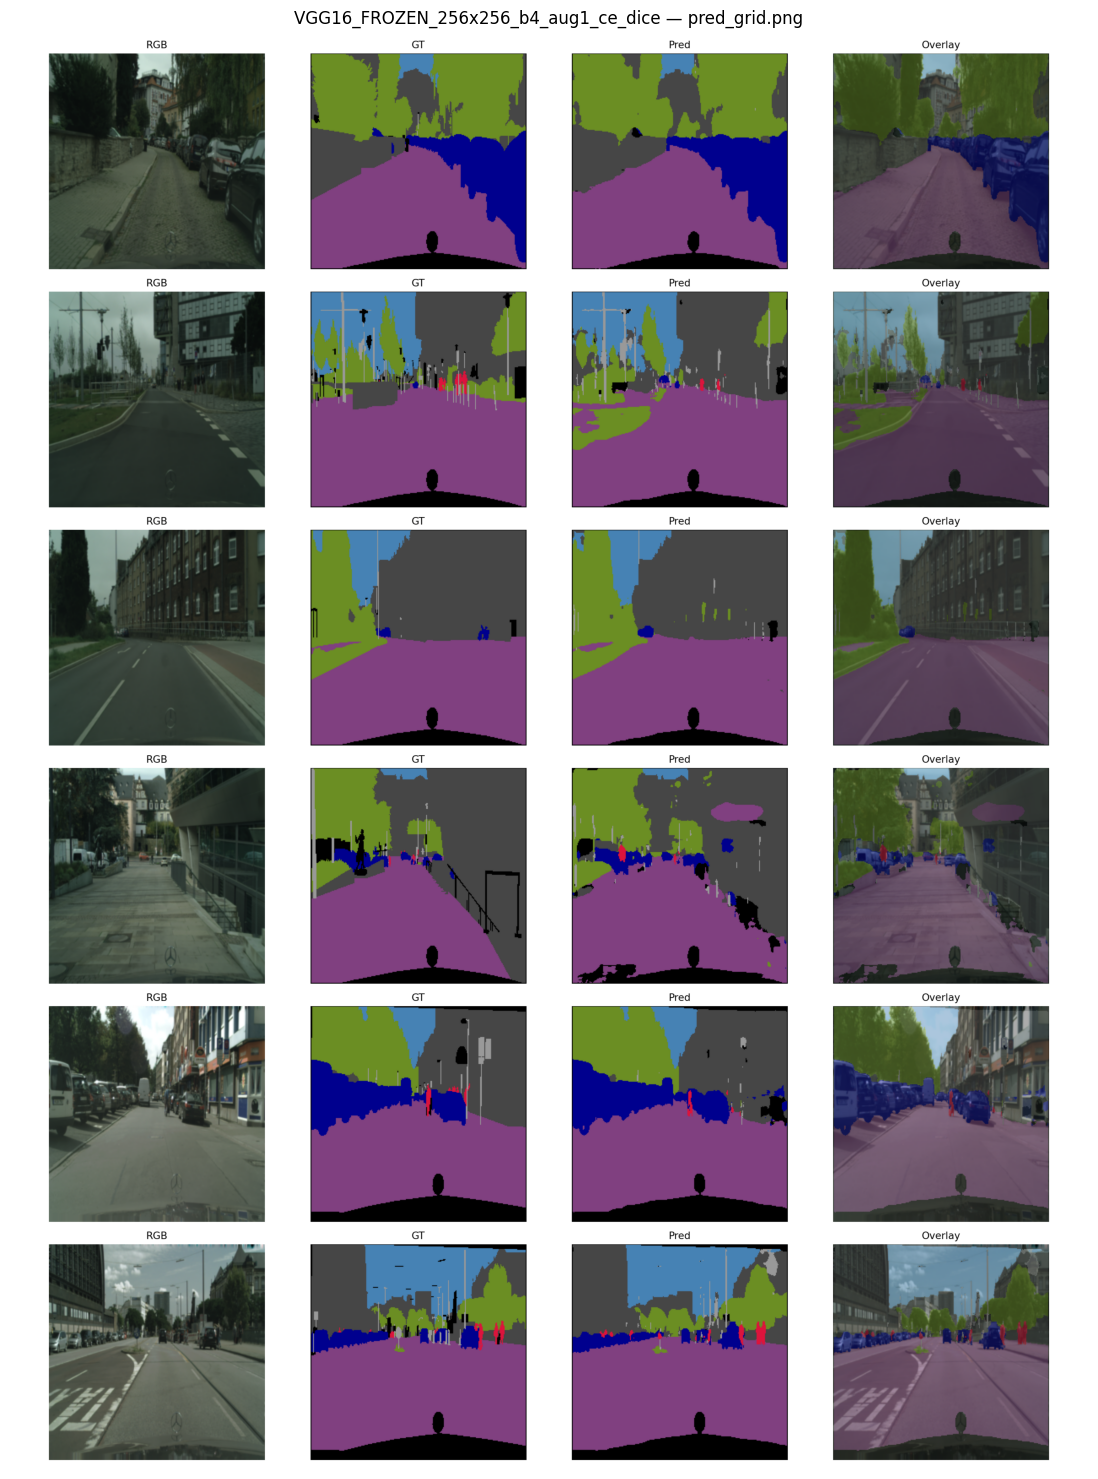

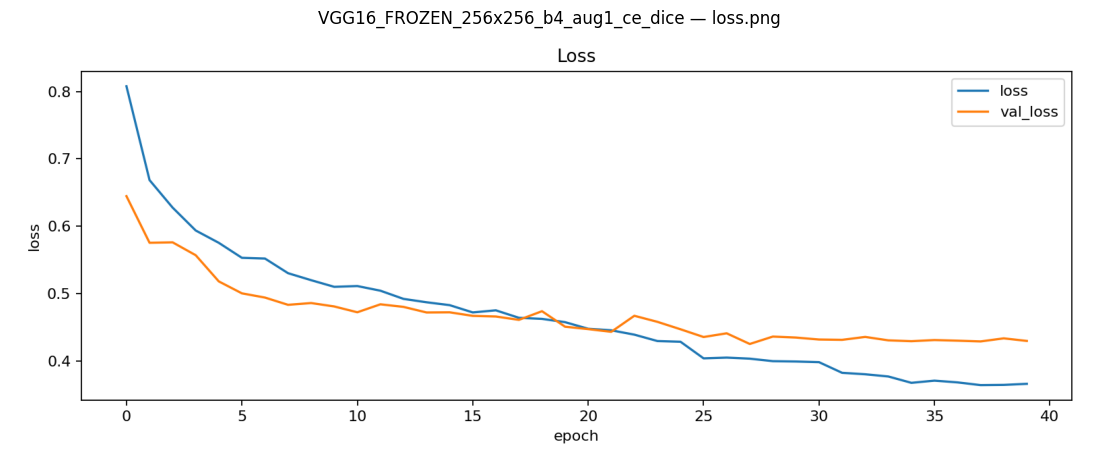

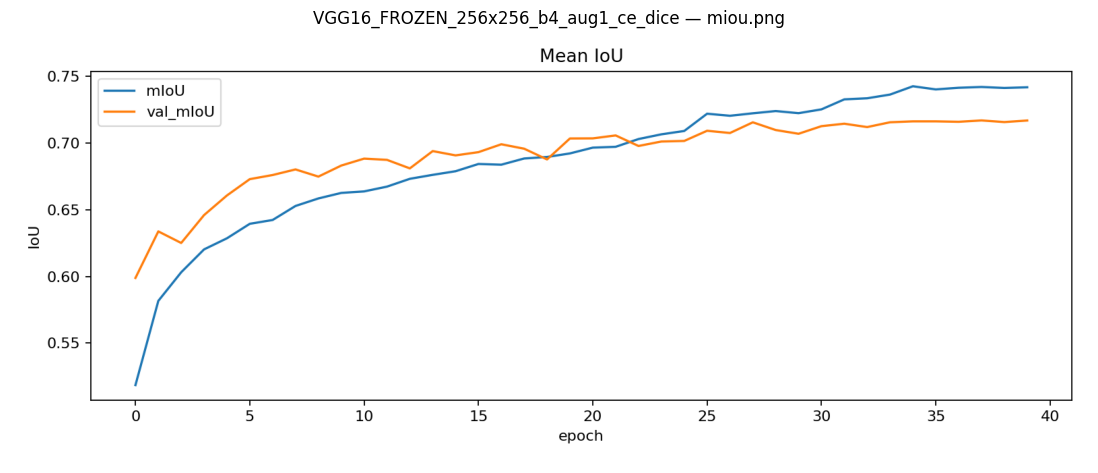

In [ ]:
def show_image(path, title=None, max_w=1200):
    img = Image.open(path)
    w, h = img.size
    scale = min(1.0, max_w / w)
    plt.figure(figsize=(scale * w / 100, scale * h / 100))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def show_run_visuals(run_name):
    rd = RUNS_ROOT / run_name
    candidates = [
        "pred_grid.png",
        "predictions.png",
        "overlay.png",
        "overlay_pred.png",
        "loss.png",
        "miou.png",
        "mIoU.png",
    ]
    found = [rd / c for c in candidates if (rd / c).exists()]
    print("Run:", run_name)
    print("Found images:", [p.name for p in found])

    for p in found:
        show_image(p, title=f"{run_name} — {p.name}", max_w=1400)


top2 = df.sort_values("score_main", ascending=False).head(5)["run_name"].tolist()
for rn in top2:
    show_run_visuals(rn)

In [ ]:
def quick_report(top_k=5):
    d = df.sort_values("score_main", ascending=False).head(top_k)
    lines = []
    for _, r in d.iterrows():
        lines.append(
            f"- {r['run_name']} | score={r['score_main']:.4f} | "
            f"enc={r['encoder']} | size={r['size_hw']} | batch={r['batch']} | "
            f"aug={r['aug']} rep={r['aug_repeats']} | loss={r['loss_name']}"
        )
    return "\n".join(lines)


print(quick_report(10))

- UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e40_seed42 | score=0.7719 | enc=scratch | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- VGG16_FT_256x256_b4_aug1_ce_dice | score=0.7688 | enc=vgg16 | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- RESNET50_FT_256x256_b4_aug1_ce_dice | score=0.7665 | enc=resnet50 | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- RESNET50_FROZEN_256x256_b4_aug1_ce_dice | score=0.7639 | enc=resnet50 | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- VGG16_FROZEN_256x256_b4_aug1_ce_dice | score=0.7398 | enc=vgg16 | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- UNET_SCRATCH_256x256_b4_aug1_rep1_ce_dice_e10_seed42 | score=0.6815 | enc=scratch | size=(256, 256) | batch=4 | aug=True rep=1 | loss=ce_dice
- UNET_SCRATCH_256x256_b4_aug0_rep1_ce_e5_seed42 | score=0.6710 | enc=scratch | size=(256, 256) | batch=4 | aug=False rep=1 | loss=ce
- UNET_SCRATCH_128x128_b8_aug0_rep1_ce_e5_seed42 | score=0.6488 | enc=